# derived_8.2-error-analysis-1.0: Per-Regime Performance Gap & Model 7/8 Discrete Output Analysis

This experiment performs a comprehensive diagnostic error analysis on the 18 models evaluated in `derived_8.2-eval-3.3`. 

We focus on two major phenomena:
1. **Per-Regime Performance Gap**: Regime 0 (dry/low moisture) maintains high $R^2 \approx 0.66\text{--}0.74$, whereas Regime 1 (wet/high moisture) drops to $R^2 \approx -0.09\text{--}0.54$.
2. **Model 7 & Model 8 Discrete Step Predictions**: Models 7 and 8 output discrete step predictions in Regime 1 instead of continuous predictions.


## Section 1: Environment Setup & Data Ingestion

We load the required Python libraries (pandas, numpy, matplotlib, seaborn), set random seeds, locate project paths, and load test dataset `data/splits/derived_8.2/test.csv` alongside model prediction outputs saved during `derived_8.2-eval-3.3`.

In [1]:
import sys
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial"]

exp_dir = Path(".").resolve()
notebooks_dir = exp_dir.parent.parent
project_root = notebooks_dir.parent

sys.path.insert(0, str(project_root))

eval33_dir = notebooks_dir / "experiment" / "derived_8.2-eval-3.3"
eval33_models_dir = eval33_dir / "models"
split_dir = project_root / "data" / "splits" / "derived_8.2"

test_df = pd.read_csv(split_dir / "test.csv")
y_test = test_df["soil_moisture_5cm"].values

test_df["date_parsed"] = pd.to_datetime(test_df["date"])
test_df["month"] = test_df["date_parsed"].dt.month

per_regime_summary = pd.read_csv(eval33_dir / "per_regime_metrics_summary.csv")
print(f"Loaded test set ({len(test_df)} samples) and per-regime summary from eval-3.3.")

Loaded test set (8902 samples) and per-regime summary from eval-3.3.


C:\Users\pan\AppData\Local\Temp\ipykernel_15300\3958914220.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_df["date_parsed"] = pd.to_datetime(test_df["date"])
C:\Users\pan\AppData\Local\Temp\ipykernel_15300\3958914220.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_df["month"] = test_df["date_parsed"].dt.month


## Section 2: Target Variance Decomposition per Regime

We compute target variance $\text{Var}(y)$, model error MSE, $R^2$, and normalized RMSE ($\text{nRMSE} = \frac{\text{RMSE}}{\text{Std}(y)}$) for Regime 0 and Regime 1 across all 18 models. This tests whether lower $R^2$ in Regime 1 is caused by target variance compression or absolute error increase.

In [2]:
detailed_metrics = []

for idx, row in per_regime_summary.iterrows():
    mid = int(row["Model ID"])
    mname = row["Model Name"]
    strat = row["Strategy"]
    arm = row["Arm"]

    preds_files = list(eval33_models_dir.glob(f"model_{mid}_*_preds.npy"))
    labels_files = list(eval33_models_dir.glob(f"model_{mid}_*_labels_te.npy"))
    
    if not preds_files or not labels_files:
        continue
    
    preds = np.load(preds_files[0])
    labels_te = np.load(labels_files[0])

    mask0 = (labels_te == 0)
    mask1 = (labels_te == 1)

    y0 = y_test[mask0]
    p0 = preds[mask0]
    y1 = y_test[mask1]
    p1 = preds[mask1]

    var_y0 = np.var(y0) if len(y0) > 0 else np.nan
    var_y1 = np.var(y1) if len(y1) > 0 else np.nan

    mse0 = np.mean((y0 - p0)**2) if len(y0) > 0 else np.nan
    mse1 = np.mean((y1 - p1)**2) if len(y1) > 0 else np.nan

    rmse0 = np.sqrt(mse0) if len(y0) > 0 else np.nan
    rmse1 = np.sqrt(mse1) if len(y1) > 0 else np.nan

    r2_0 = 1.0 - (mse0 / var_y0) if var_y0 > 0 else np.nan
    r2_1 = 1.0 - (mse1 / var_y1) if var_y1 > 0 else np.nan

    nrmse_0 = rmse0 / np.std(y0) if np.std(y0) > 0 else np.nan
    nrmse_1 = rmse1 / np.std(y1) if np.std(y1) > 0 else np.nan

    detailed_metrics.append({
        "Model ID": mid,
        "Model Name": mname,
        "Strategy": strat,
        "Arm": arm,
        "N_R0": len(y0),
        "Var_y_R0": var_y0,
        "MSE_R0": mse0,
        "RMSE_R0": rmse0,
        "nRMSE_R0": nrmse_0,
        "R2_R0": r2_0,
        "N_R1": len(y1),
        "Var_y_R1": var_y1,
        "MSE_R1": mse1,
        "RMSE_R1": rmse1,
        "nRMSE_R1": nrmse_1,
        "R2_R1": r2_1,
    })

det_df = pd.DataFrame(detailed_metrics)
print("=== PER-REGIME TARGET VARIANCE DECOMPOSITION ===")
print(det_df[["Model ID", "Strategy", "Arm", "Var_y_R0", "MSE_R0", "R2_R0", "nRMSE_R0", "Var_y_R1", "MSE_R1", "R2_R1", "nRMSE_R1"]].to_string(index=False))

=== PER-REGIME TARGET VARIANCE DECOMPOSITION ===
 Model ID              Strategy       Arm  Var_y_R0   MSE_R0    R2_R0  nRMSE_R0  Var_y_R1   MSE_R1     R2_R1  nRMSE_R1
        3     trained_gating_k2  spec_old  0.004319 0.003275 0.241757  0.870772  0.005054 0.005527 -0.093787  1.045843
        4     trained_gating_k2  spec_new  0.004319 0.003365 0.220816  0.882714  0.005054 0.005341 -0.056880  1.028047
        5     trained_gating_k2 global_v3  0.004319 0.003357 0.222754  0.881615  0.005054 0.005380 -0.064639  1.031813
        6     trained_gating_k2 global_c1  0.004319 0.003195 0.260167  0.860135  0.005054 0.004876  0.035043  0.982322
        7   Univariate_G_API_k2  spec_old  0.011846 0.003344 0.717706  0.531313  0.008141 0.007055  0.133493  0.930864
        8   Univariate_G_API_k2  spec_new  0.011846 0.003384 0.714342  0.534470  0.008141 0.007055  0.133493  0.930864
        9   Univariate_G_API_k2 global_v3  0.011846 0.003314 0.720239  0.528924  0.008141 0.004769  0.414242  0.765348

## Section 3: Model 7 & Model 8 Discrete Step Output Anomaly

We inspect why Model 7 (`Univariate G_API K=2 Spec-old`) and Model 8 (`Univariate G_API K=2 Spec-new`) output discrete step predictions in Regime 1 by verifying their selected feature sets and grouping predictions against the discrete spatial feature `J_aspect_deg`.

In [3]:
with open(eval33_dir / "previous_features.json", "r") as f:
    prev_features = json.load(f)
with open(eval33_dir / "selected_features.json", "r") as f:
    sel_features = json.load(f)

m7_features_c1 = prev_features["clusters"]["Univariate_G_API_k2"]["1"]["features"]
m8_features_c1 = sel_features["clusters"]["Univariate_G_API_k2"]["1"]["features"]

print(f"Model 7 Cluster 1 Feature Set: {m7_features_c1}")
print(f"Model 8 Cluster 1 Feature Set: {m8_features_c1}")

m7_preds = np.load(list(eval33_models_dir.glob("model_7_*_preds.npy"))[0])
m10_preds = np.load(list(eval33_models_dir.glob("model_10_*_preds.npy"))[0])
g_api_mask1 = (test_df["G_API"] >= 0.16).values

discrete_df = pd.DataFrame({
    "J_aspect_deg": test_df.loc[g_api_mask1, "J_aspect_deg"].values,
    "Model_7_Pred": m7_preds[g_api_mask1],
    "Model_10_Pred": m10_preds[g_api_mask1],
    "Ground_Truth": y_test[g_api_mask1]
})

grouped = discrete_df.groupby("J_aspect_deg").agg(
    Count=("Model_7_Pred", "count"),
    M7_Pred_Mean=("Model_7_Pred", "mean"),
    M7_Pred_Std=("Model_7_Pred", "std"),
    GroundTruth_Mean=("Ground_Truth", "mean")
).reset_index()

print("\nModel 7 Predictions grouped by J_aspect_deg in Cluster 1:")
print(grouped.to_string(index=False))

Model 7 Cluster 1 Feature Set: ['J_aspect_deg']
Model 8 Cluster 1 Feature Set: ['J_aspect_deg']

Model 7 Predictions grouped by J_aspect_deg in Cluster 1:
 J_aspect_deg  Count  M7_Pred_Mean  M7_Pred_Std  GroundTruth_Mean
           68    626      0.292225     0.068867          0.234479
           97    171      0.195594     0.017347          0.198491
          107    999      0.217530     0.093308          0.204229
          143   1044      0.199307     0.059976          0.241026
          151    895      0.160148     0.103579          0.159897
          153    906      0.242256     0.082771          0.238189
          180    790      0.288398     0.083037          0.186234
          223     89      0.171704     0.132611          0.153820
          234   1081      0.193923     0.086753          0.188818
          240   1067      0.192659     0.076357          0.169734
          298    986      0.129599     0.037062          0.110953
          354    246      0.088844     0.013533      

## Section 4: Monthly Residual Breakdown & Hydrological Error Drivers

We examine month-by-month performance and residuals for Model 14 (Cluster K=2 Global-c1) against precipitation and target variance to pinpoint hydrological error drivers (e.g. October autumn rain transition crash).

In [4]:
test_df["residual_M14"] = y_test - np.load(list(eval33_models_dir.glob("model_14_*_preds.npy"))[0])
test_df["residual_M2"] = y_test - np.load(list(eval33_models_dir.glob("model_2_*_preds.npy"))[0])

monthly_stats = []
for m in range(1, 13):
    m_mask = (test_df["month"] == m).values
    y_m = y_test[m_mask]
    res14_m = test_df.loc[m_mask, "residual_M14"].values
    precip_m = test_df.loc[m_mask, "precip_mm"].values

    if len(y_m) > 0:
        monthly_stats.append({
            "Month": m,
            "N": len(y_m),
            "Target_Mean": np.mean(y_m),
            "Target_Var": np.var(y_m),
            "Precip_Mean": np.mean(precip_m),
            "RMSE_M14": np.sqrt(np.mean(res14_m**2)),
            "R2_M14": 1.0 - np.mean(res14_m**2)/np.var(y_m) if np.var(y_m)>0 else np.nan,
        })

month_df = pd.DataFrame(monthly_stats)
print("=== MONTHLY PERFORMANCE & HYDROLOGICAL BREAKDOWN ===")
print(month_df.round(4).to_string(index=False))

=== MONTHLY PERFORMANCE & HYDROLOGICAL BREAKDOWN ===
 Month   N  Target_Mean  Target_Var  Precip_Mean  RMSE_M14  R2_M14
     1 779       0.2130      0.0084       6.6141    0.0577  0.6063
     2 701       0.2164      0.0078       7.4845    0.0611  0.5211
     3 825       0.2397      0.0079       5.7166    0.0532  0.6419
     4 780       0.2569      0.0066       4.3258    0.0441  0.7049
     5 807       0.2512      0.0075       2.1326    0.0483  0.6895
     6 801       0.1973      0.0099       2.1866    0.0647  0.5771
     7 753       0.0919      0.0036       0.6600    0.0497  0.3128
     8 699       0.0737      0.0042       1.9290    0.0517  0.3619
     9 688       0.0818      0.0057       2.1625    0.0698  0.1445
    10 709       0.1474      0.0085       5.1776    0.0924 -0.0039
    11 637       0.2095      0.0057       8.9843    0.0717  0.1061
    12 723       0.2345      0.0064      12.2237    0.0582  0.4725


C:\Users\pan\AppData\Local\Temp\ipykernel_15300\1241746980.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_df["residual_M14"] = y_test - np.load(list(eval33_models_dir.glob("model_14_*_preds.npy"))[0])
C:\Users\pan\AppData\Local\Temp\ipykernel_15300\1241746980.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_df["residual_M2"] = y_test - np.load(list(eval33_models_dir.glob("model_2_*_preds.npy"))[0])


## Section 5: Visualization & Diagnostic Visual Summary

We generate diagnostic visual figures illustrating target variance decomposition, Model 7 discrete step function behavior, and monthly hydrological error patterns.

Displaying: target_variance_and_r2_by_regime.png


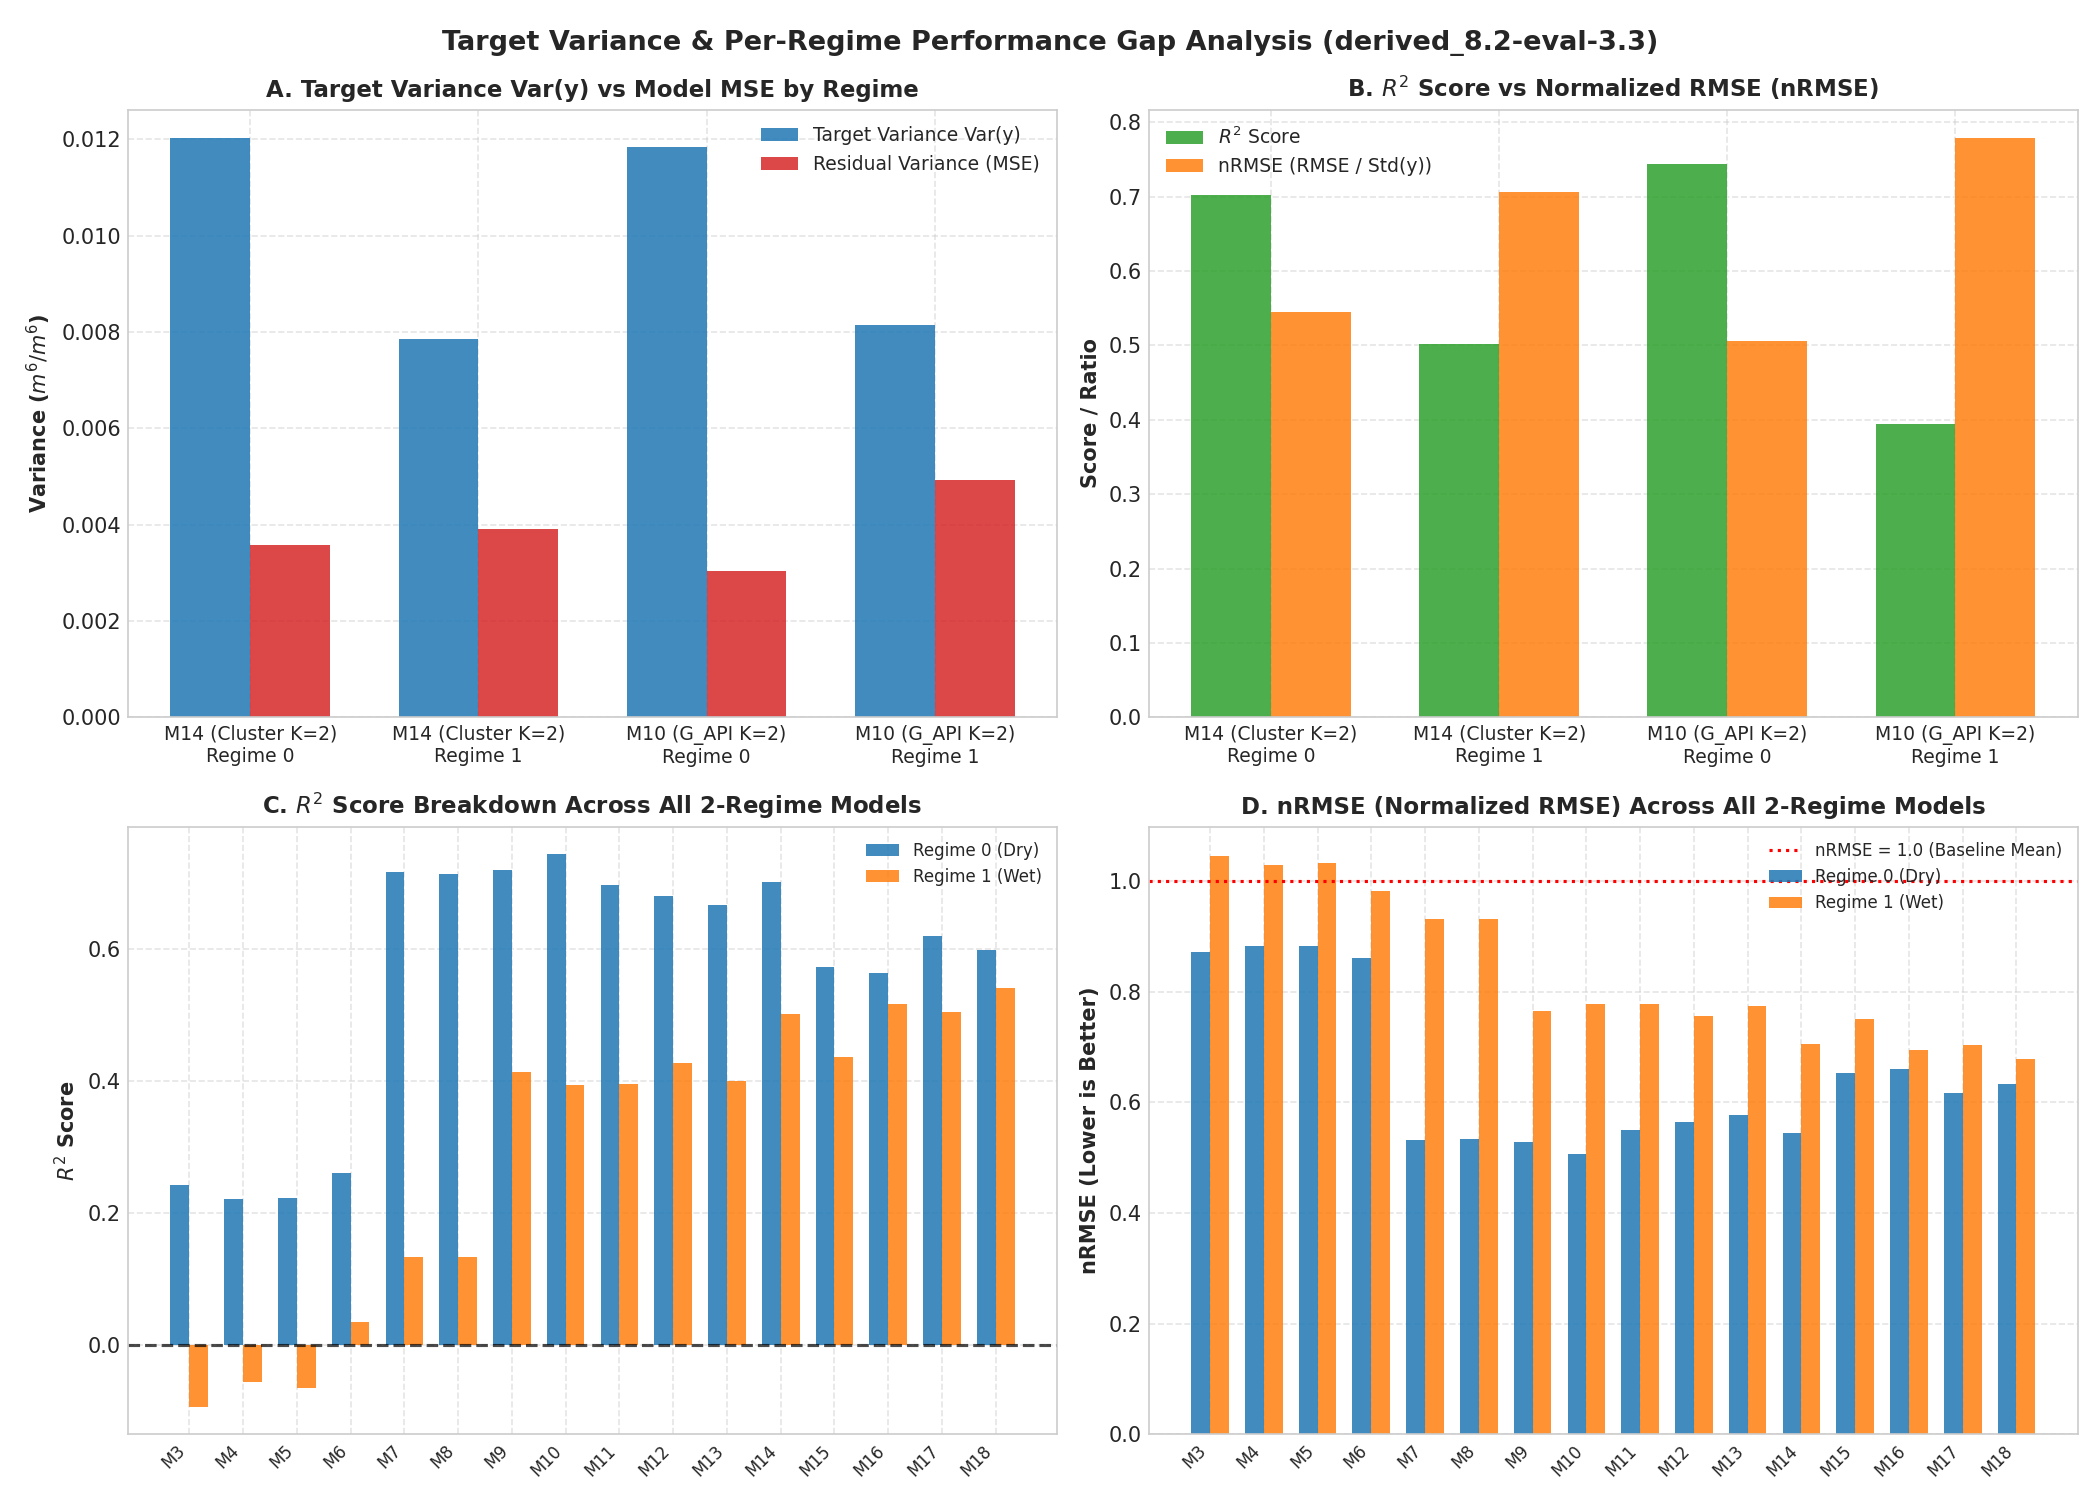

Displaying: model7_8_discrete_step_analysis.png


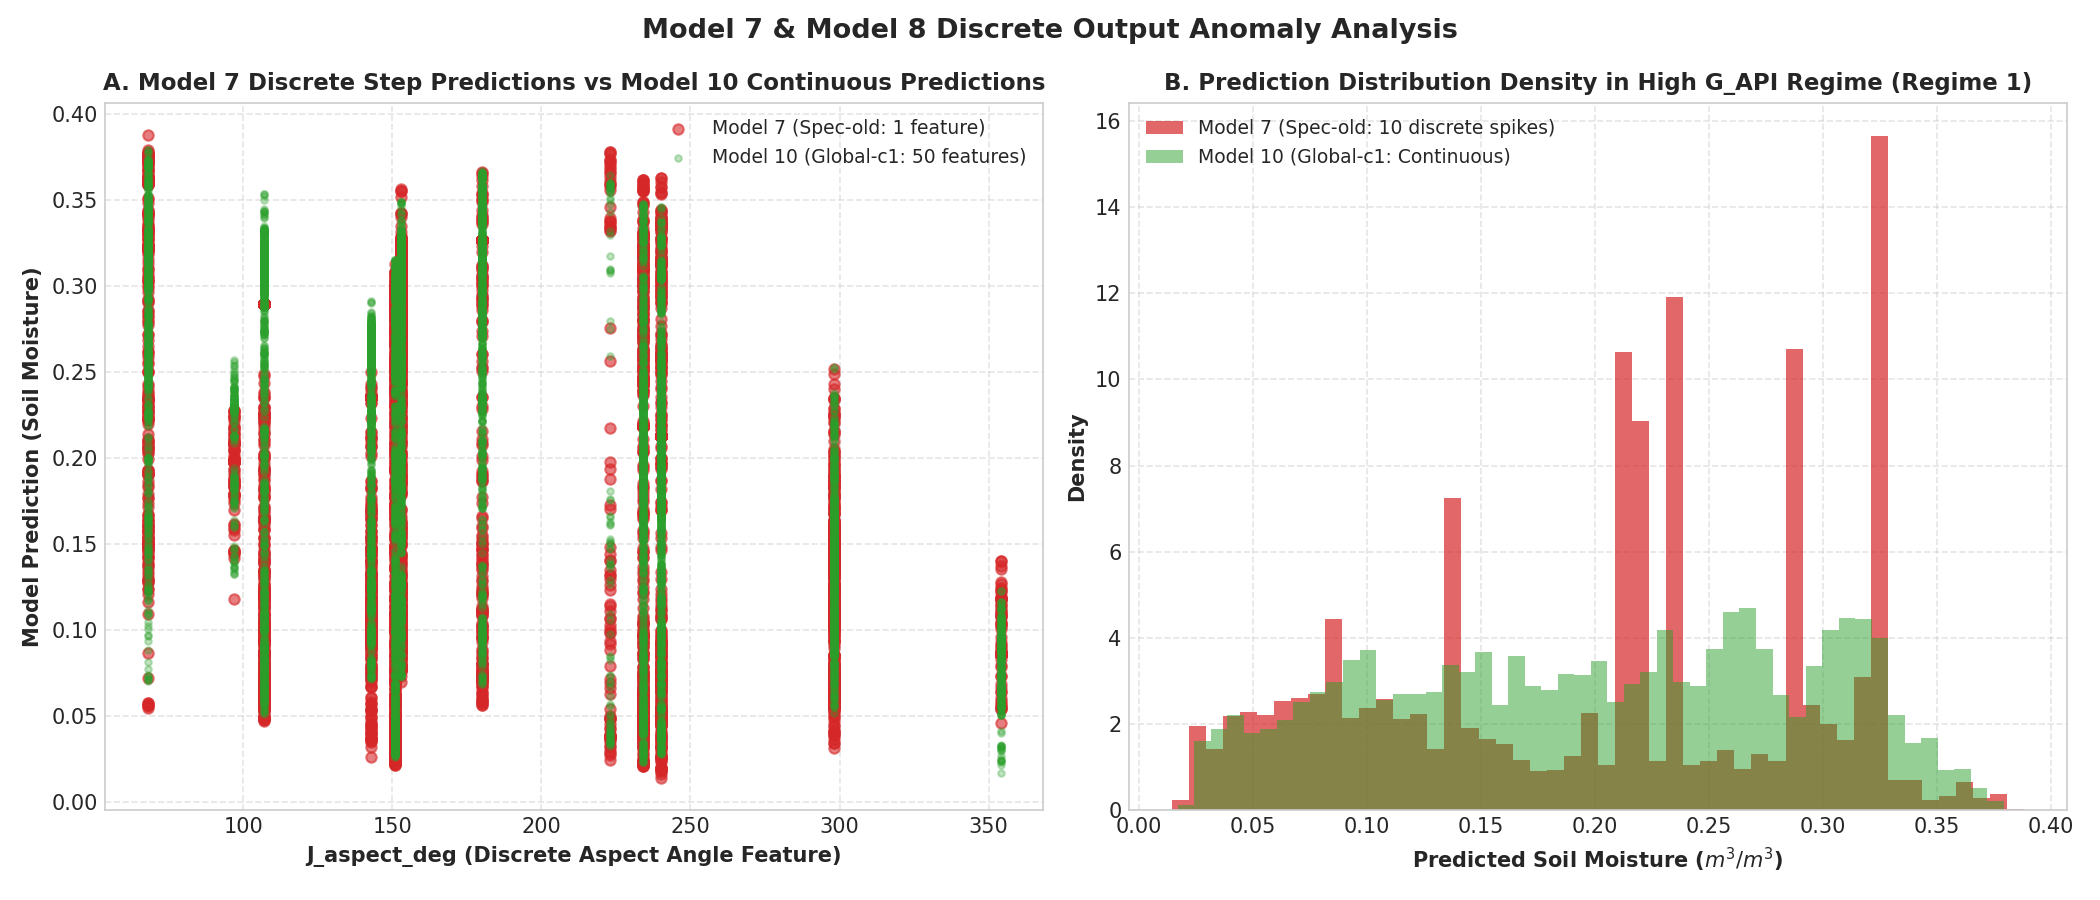

Displaying: monthly_residual_and_variance.png


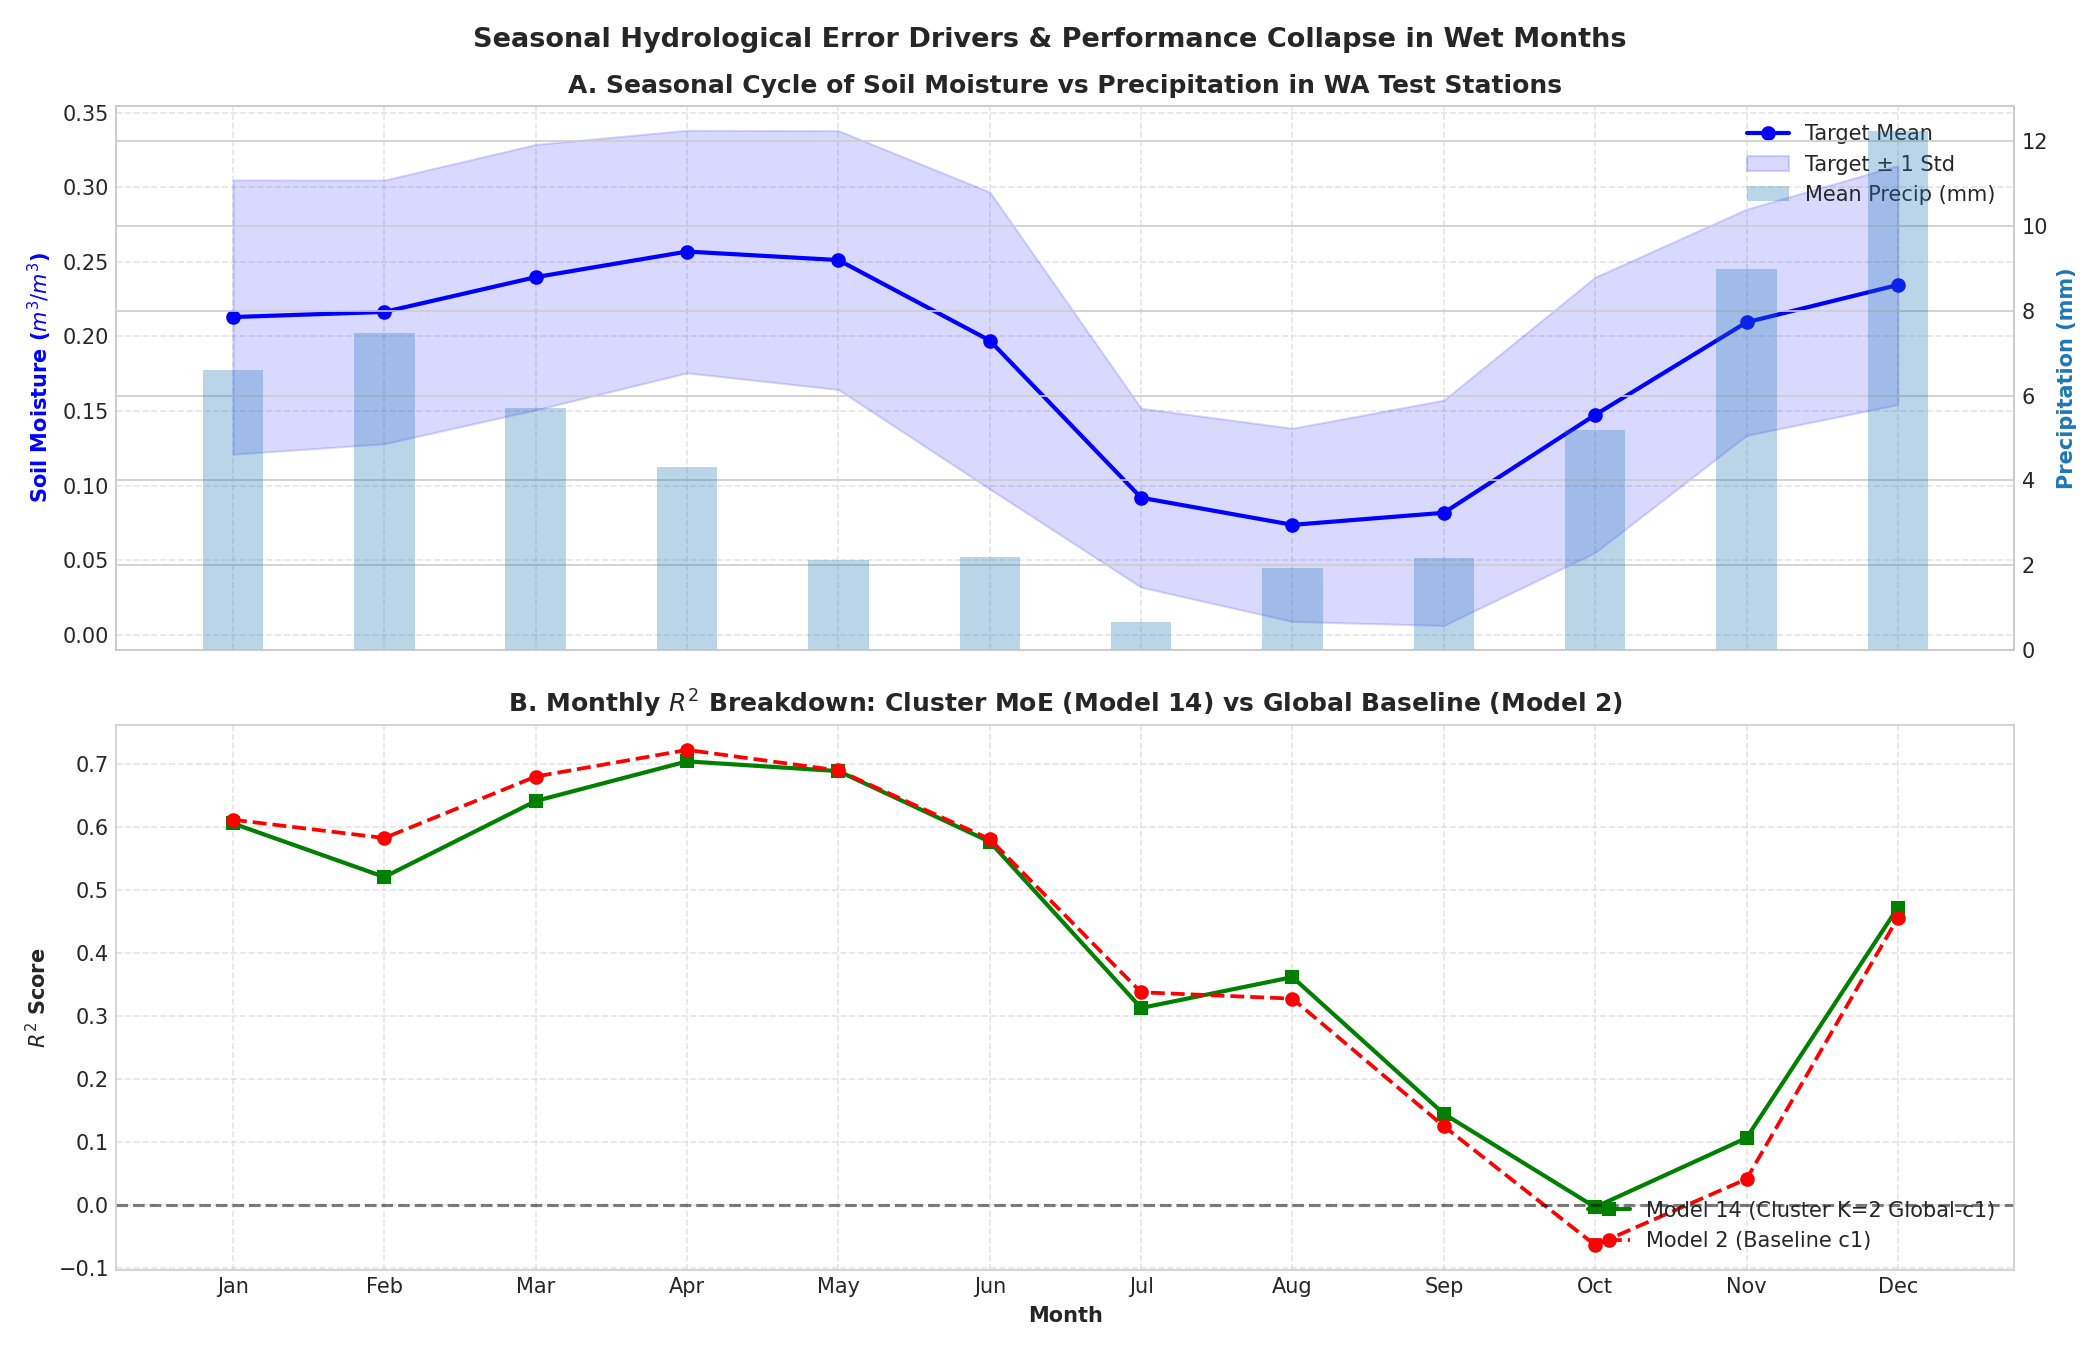

In [5]:
# Display figures generated during error analysis
from IPython.display import Image, display

for fig_name in [
    "target_variance_and_r2_by_regime.png",
    "model7_8_discrete_step_analysis.png",
    "monthly_residual_and_variance.png"
]:
    fig_path = exp_dir / fig_name
    if fig_path.exists():
        print(f"Displaying: {fig_name}")
        display(Image(filename=str(fig_path)))